# CEREBRO PoC — 04 Knowledge Visualization

**Experiment:** EXP-VIS-001  
**Stage:** Knowledge Visualization  
**Input:** Persisted Knowledge Model `KM-0001`  
**Views:** Knowledge Galaxy + Knowledge Timeline + Assisted Recollection

---

## Objective

Validate that CEREBRO's persisted knowledge model can support multiple interconnected views of the same knowledge.

This experiment renders:

- **Knowledge Galaxy** — semantic relationships between knowledge fragments.
- **Knowledge Timeline** — temporal placement of knowledge fragments and events.
- **Assisted Recollection** — navigation from knowledge back to its supporting source evidence.

### Core Principle

**One Knowledge Model → Multiple Views**

The Galaxy and Timeline do not maintain separate copies of knowledge.

Both are projections of the same underlying knowledge fragments, relationships, temporal metadata, and provenance.

`KM-0001 → Galaxy / Timeline → Assisted Recollection → Source Evidence`

### 1 — Load persisted model

In [1]:
from pathlib import Path
import json

repo_root = Path.cwd().parents[1]

model_path = (
    repo_root
    / "poc/data/processed/knowledge/KM-0001.json"
)

assert model_path.exists()

with open(model_path, "r", encoding="utf-8") as f:
    knowledge_model = json.load(f)

fragments = knowledge_model["fragments"]
relationships = knowledge_model["relationships"]

print("✓ Knowledge model loaded")
print("Fragments    :", len(fragments))
print("Relationships:", len(relationships))

✓ Knowledge model loaded
Fragments    : 3
Relationships: 3


### 2 - Knowledge Galaxy

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for fragment in fragments:

    concepts = fragment["semantic"]["concepts"]

    label = (
        concepts[0]
        if concepts
        else fragment["fragment_id"]
    )

    G.add_node(
        fragment["fragment_id"],
        label=label
    )

for relationship in relationships:

    G.add_edge(
        relationship["source"],
        relationship["target"],
        relationship_type=relationship["type"]
    )

print("✓ Galaxy graph constructed")

Matplotlib is building the font cache; this may take a moment.


✓ Galaxy graph constructed


### 3 — Render it

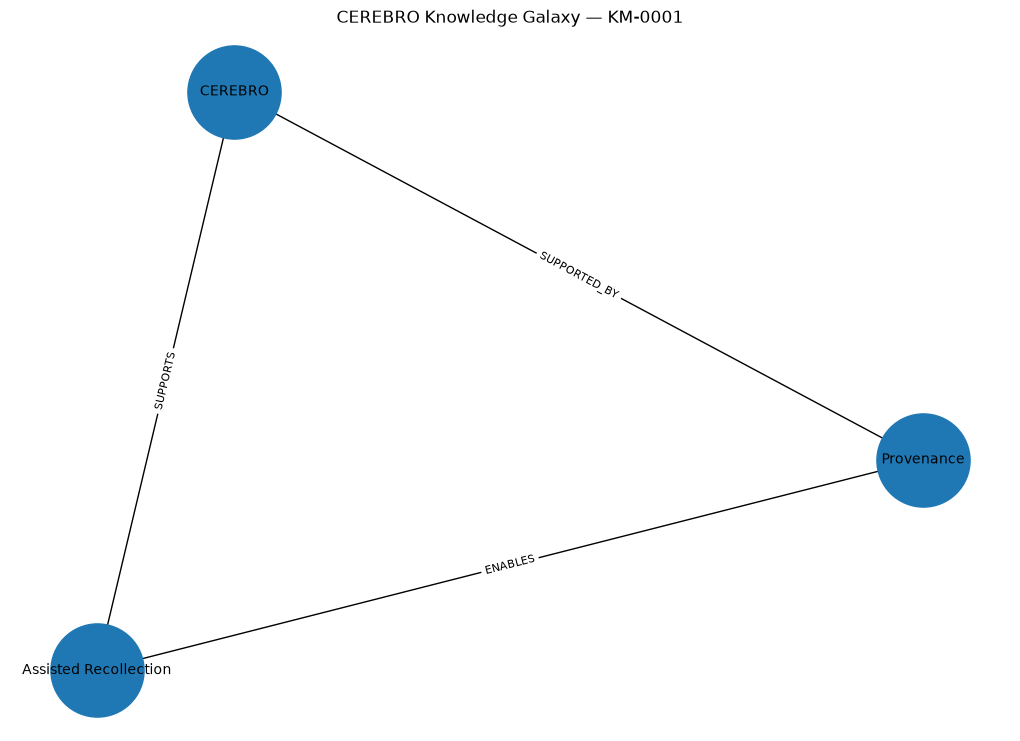

In [4]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

labels = {
    node: G.nodes[node]["label"]
    for node in G.nodes
}

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=4500,
    font_size=10
)

edge_labels = {
    (u, v): data["relationship_type"]
    for u, v, data in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title(
    "CEREBRO Knowledge Galaxy — KM-0001"
)

plt.axis("off")
plt.show()

### 4. Knowledge timeline

In [5]:
from datetime import datetime

timeline_events = []

for fragment in fragments:

    temporal = fragment["temporal"]

    if temporal["ingested_at"]:

        timestamp = datetime.fromisoformat(
            temporal["ingested_at"]
        )

        concepts = fragment[
            "semantic"
        ]["concepts"]

        label = (
            concepts[0]
            if concepts
            else fragment["fragment_id"]
        )

        timeline_events.append({
            "fragment_id": fragment["fragment_id"],
            "timestamp": timestamp,
            "label": label,
            "event_type": "ingested"
        })

print(
    f"✓ {len(timeline_events)} "
    "timeline events prepared"
)

✓ 3 timeline events prepared


### 5 — Render Timeline

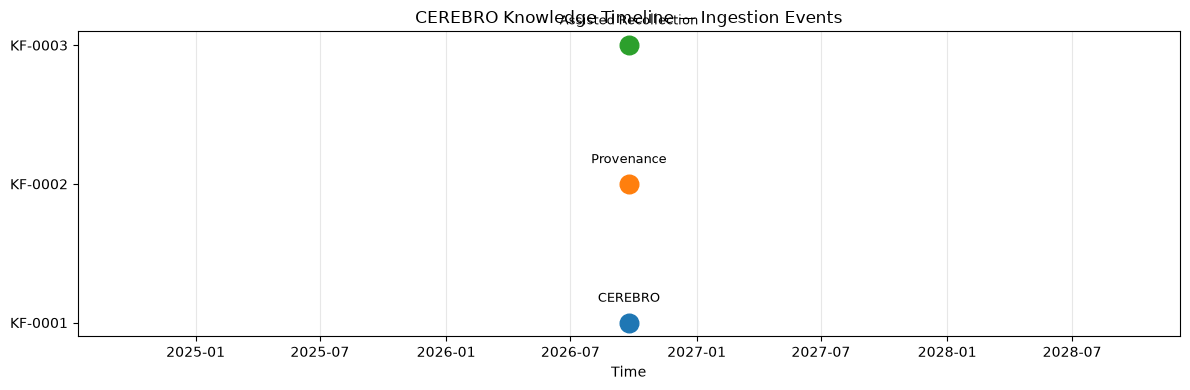

In [6]:
plt.figure(figsize=(12, 4))

for index, event in enumerate(timeline_events):

    plt.scatter(
        event["timestamp"],
        index,
        s=180
    )

    plt.text(
        event["timestamp"],
        index + 0.15,
        event["label"],
        ha="center",
        fontsize=9
    )

plt.yticks(
    range(len(timeline_events)),
    [
        event["fragment_id"]
        for event in timeline_events
    ]
)

plt.xlabel("Time")
plt.title(
    "CEREBRO Knowledge Timeline — Ingestion Events"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 6 - Assisted Recollection

In [7]:
def recollect(fragment_id):

    fragment = next(
        fragment
        for fragment in fragments
        if fragment["fragment_id"] == fragment_id
    )

    location = fragment["source_location"]

    source_path = (
        repo_root
        / "poc/data/raw/text/benchmark_001.txt"
    )

    source_text = source_path.read_text(
        encoding="utf-8"
    )

    evidence = source_text[
        location["start"]:
        location["end"]
    ]

    related = []

    for relationship in relationships:

        if relationship["source"] == fragment_id:
            related.append(
                relationship["target"]
            )

        elif relationship["target"] == fragment_id:
            related.append(
                relationship["source"]
            )

    return {
        "fragment": fragment_id,
        "knowledge": fragment["content"],
        "concepts": fragment["semantic"]["concepts"],
        "related_fragments": related,
        "source_artifact": fragment["artifact_id"],
        "source_file": fragment[
            "provenance"
        ]["source_filename"],
        "source_location": location,
        "evidence": evidence
    }

In [8]:
result = recollect("KF-0002")

for key, value in result.items():
    print(f"{key}: {value}")

fragment: KF-0002
knowledge: It maintains provenance between knowledge fragments and their original source artifacts.
concepts: ['Provenance', 'Knowledge Fragment', 'Source Artifact']
related_fragments: ['KF-0001', 'KF-0003']
source_artifact: ART-0001
source_file: benchmark_001.txt
source_location: {'type': 'character_range', 'start': 86, 'end': 174}
evidence: It maintains provenance between knowledge fragments and their original source artifacts.


## Experiment Conclusion

**EXP-VIS-001 — Knowledge Visualization: PASS**

CEREBRO successfully rendered multiple views from the persisted `KM-0001` knowledge model.

### What Was Demonstrated

The experiment validated a shared knowledge foundation supporting:

**Knowledge Galaxy**  
Semantic relationships between knowledge fragments can be visualized as a connected graph.

**Knowledge Timeline**  
The same knowledge fragments can be projected temporally without creating a separate knowledge store.

**Assisted Recollection**  
A selected knowledge fragment can be traced deterministically back to its registered artifact, exact source location, and supporting evidence.

### Validated Architecture

`Registered Artifact → Knowledge Model → Galaxy / Timeline → Assisted Recollection → Source Evidence`

Galaxy and Timeline are therefore different projections of the **same Digital Knowledge Twin**, rather than independent features.

### Integrity Validation

The visualization layer does not generate or modify trusted knowledge.

Knowledge identity, relationships, temporal metadata, and provenance originate from the persisted knowledge model.

Assisted Recollection can resolve source evidence without requiring an LLM, preserving deterministic traceability even when AI services are unavailable.

### Current PoC Limitations

The current benchmark is intentionally small.

Semantic relationships are based on controlled annotations, while the Timeline primarily represents verified ingestion time because the source contains no reliable historical knowledge date.

No unsupported dates are inferred.

### Next Experiment

**EXP-KNOW-002 — Embeddings & Semantic Relationship Discovery**

The next stage will introduce vector embeddings to determine whether CEREBRO can automatically discover candidate relationships between knowledge fragments.

This will evolve the Galaxy from:

**Manually Defined Relationships → Machine-Discovered Candidate Relationships → Validated Knowledge Connections**

The existing provenance model remains unchanged.